In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

print("Ambiente configurado com sucesso!")

Ambiente configurado com sucesso!


In [16]:
import re

caminho = "../Dados/LOGS_EVENTOS.txt"

with open(caminho, "r", encoding="utf-8") as arquivo:
    linhas = arquivo.readlines()

registros = []

for linha in linhas:
    linha = linha.strip()

    padrao = r"^(\w+)\s+-([\d/]+)\s+([\d:]+)\s+(.+)$"
    resultado = re.match(padrao, linha)

    if resultado:
        identificador, data, hora, evento = resultado.groups()

        registros.append([identificador,data,hora,evento])

df = pd.DataFrame(registros,columns=["identificador","data","hora","evento"])

print("Registros válidos:", len(df))
print("Registros originais:", len(linhas))

Registros válidos: 9998
Registros originais: 10000


In [17]:
df["timestamp"] = pd.to_datetime(
    df["data"] + " " + df["hora"],
    format="%Y/%m/%d %H:%M:%S"
)

df["hora_do_dia"] = df["timestamp"].dt.hour
df["minuto"] = df["timestamp"].dt.minute
df["segundo"] = df["timestamp"].dt.second
df["dia"] = df["timestamp"].dt.date

print(df[["timestamp","hora_do_dia","minuto","segundo"]].head())

            timestamp  hora_do_dia  minuto  segundo
0 2014-08-11 18:47:35           18      47       35
1 2014-08-11 18:47:35           18      47       35
2 2014-08-11 18:47:35           18      47       35
3 2014-08-11 18:47:35           18      47       35
4 2014-08-11 18:47:36           18      47       36


In [18]:
df["hora_sin"] = np.sin(2 * np.pi * df["hora_do_dia"] / 24)

df["hora_cos"] = np.cos(2 * np.pi * df["hora_do_dia"] / 24)

df["minuto_sin"] = np.sin(2 * np.pi * df["minuto"] / 60)

df["minuto_cos"] = np.cos(2 * np.pi * df["minuto"] / 60)

df["eventos_no_timestamp"] = (df.groupby("timestamp")["timestamp"].transform("count"))

df["frequencia_evento"] = (df["evento"].map(df["evento"].value_counts()))

df["frequencia_identificador"] = (df["identificador"].map(df["identificador"].value_counts()))

In [19]:
features_v1 = ["hora_sin","hora_cos","minuto_sin","minuto_cos","eventos_no_timestamp","frequencia_evento","frequencia_identificador"]

X_v1 = df[features_v1]

print("Quantidade de registros:", X_v1.shape[0])
print("Quantidade de features:", X_v1.shape[1])

Quantidade de registros: 9998
Quantidade de features: 7


In [20]:
modelo_v1 = IsolationForest(n_estimators=200,contamination="auto",random_state=42)

modelo_v1.fit(X_v1)

df["score_v1"] = modelo_v1.decision_function(X_v1)

print("Modelo 1 treinado!")

Modelo 1 treinado!


In [24]:
resultado_v1 = (df[["identificador","timestamp","evento","eventos_no_timestamp","frequencia_evento","frequencia_identificador","score_v1"]].sort_values("score_v1"))

resultado_v1.head(20)



,identificador,timestamp,evento,eventos_no_timestamp,frequencia_evento,frequencia_identificador,score_v1
5601,CWOKVK,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,3,-0.135455
5611,AWHZOX,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,3,-0.135455
5576,VEHSWW,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,3,-0.135455
5600,UNNHSK,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,5,-0.134532
5571,YSNDFM,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,29,-0.131123
5585,QQCREB,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,29,-0.131123
5609,QIYYFL,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,29,-0.131123
5589,XEBTTG,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,29,-0.131123
5596,QPNJNH,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,29,-0.131123
5597,MGZCIM,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,29,-0.131123


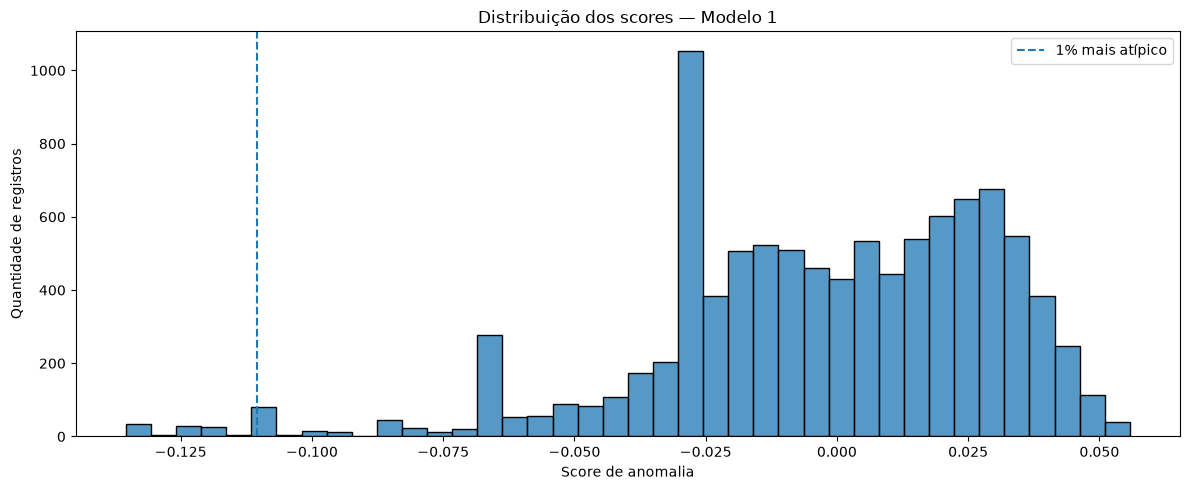

In [25]:
plt.figure(figsize=(12, 5))

sns.histplot(df["score_v1"],bins=40)

plt.axvline(df["score_v1"].quantile(0.01),linestyle="--",label="1% mais atípico")

plt.xlabel("Score de anomalia")
plt.ylabel("Quantidade de registros")
plt.title("Distribuição dos scores — Modelo 1")
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
df["log_eventos_timestamp"] = np.log1p(df["eventos_no_timestamp"])

df["log_frequencia_evento"] = np.log1p(df["frequencia_evento"])

df["log_frequencia_identificador"] = np.log1p(df["frequencia_identificador"])

features_v2 = ["hora_sin","hora_cos","minuto_sin","minuto_cos","log_eventos_timestamp","log_frequencia_evento","log_frequencia_identificador"]

X_v2 = df[features_v2]

print("Quantidade de registros:", X_v2.shape[0])
print("Quantidade de features:", X_v2.shape[1])

Quantidade de registros: 9998
Quantidade de features: 7


In [27]:
modelo_v2 = IsolationForest(n_estimators=200,contamination="auto",random_state=42)

modelo_v2.fit(X_v2)

df["score_v2"] = modelo_v2.decision_function(X_v2)

print("Modelo 2 treinado!")


Modelo 2 treinado!


In [28]:
resultado_v2 = (df[["identificador","timestamp","evento","eventos_no_timestamp","frequencia_evento","frequencia_identificador","score_v2"]].sort_values("score_v2"))

resultado_v2.head(20)

,identificador,timestamp,evento,eventos_no_timestamp,frequencia_evento,frequencia_identificador,score_v2
5576,VEHSWW,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,3,-0.162029
5611,AWHZOX,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,3,-0.162029
5601,CWOKVK,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,3,-0.162029
45,CWOKVK,2014-08-11 18:47:57,370-1-1-1-000-0,49,33,3,-0.159734
55,AWHZOX,2014-08-11 18:47:57,370-1-1-1-000-0,49,33,3,-0.159734
20,VEHSWW,2014-08-11 18:47:57,370-1-1-1-000-0,49,33,3,-0.159734
5600,UNNHSK,2014-08-12 12:24:06,358-1-1-1-000-0,47,33,5,-0.158673
44,UNNHSK,2014-08-11 18:47:57,370-1-1-1-000-0,49,33,5,-0.154762
224,AWHZOX,2014-08-11 19:06:01,581-1-1-1-000-0,49,33,3,-0.147402
189,VEHSWW,2014-08-11 19:06:01,581-1-1-1-000-0,49,33,3,-0.147402


In [33]:
limite_v2 = df["score_v2"].quantile(0.01)

df["possivel_anomalia"] = (df["score_v2"] <= limite_v2)

anomalias = df[df["possivel_anomalia"]].copy()

print("Limite de score:", limite_v2)
print("Total de registros:", len(df))
print("Registros classificados como possíveis anomalias:", len(anomalias))
print("Percentual:", f"{len(anomalias) / len(df) * 100:.2f}%")



Limite de score: -0.12416942251985452
Total de registros: 9998
Registros classificados como possíveis anomalias: 107
Percentual: 1.07%


In [34]:
resumo_anomalias = (anomalias.groupby("timestamp").agg(quantidade=("evento", "size"),eventos_diferentes=("evento", "nunique"),identificadores_diferentes=("identificador", "nunique"),score_minimo=("score_v2", "min")).sort_values("quantidade", ascending=False))

resumo_anomalias.head(10)

,quantidade,eventos_diferentes,identificadores_diferentes,score_minimo
timestamp,,,,
2014-08-11 18:47:57,36,2,36,-0.159734
2014-08-11 19:06:01,36,2,36,-0.147402
2014-08-12 12:24:06,34,2,34,-0.162029
2014-08-12 06:01:12,1,1,1,-0.133883


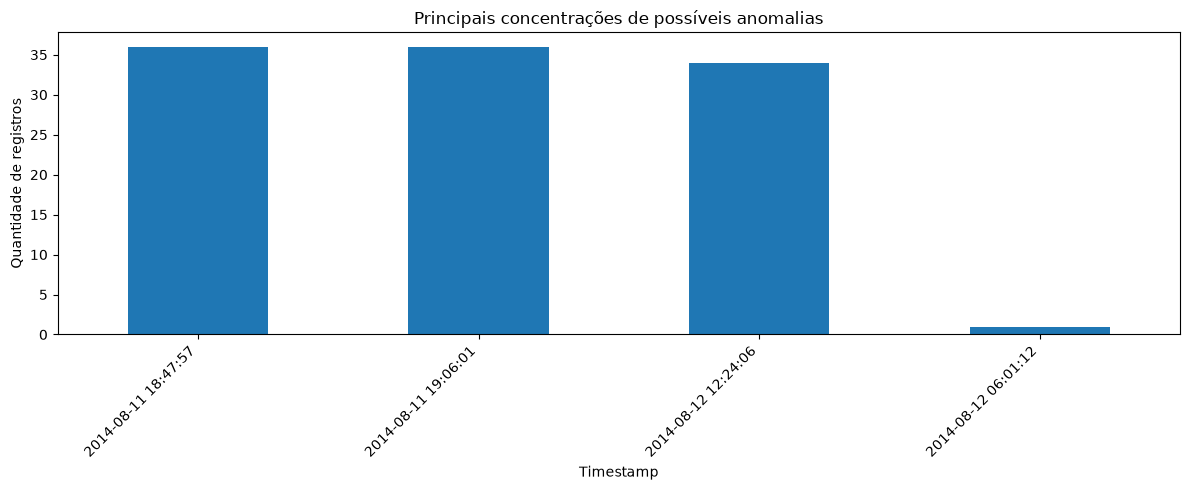

In [35]:
top_timestamps = resumo_anomalias.head(10)

plt.figure(figsize=(12, 5))

top_timestamps["quantidade"].plot(kind="bar")

plt.title("Principais concentrações de possíveis anomalias")
plt.xlabel("Timestamp")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [30]:
print("Eventos nos registros mais atípicos:")

print(anomalias["evento"].value_counts().head(15))

print("\nIdentificadores nos registros mais atípicos:")

print(anomalias["identificador"].value_counts().head(15))

print("\nHorários nos registros mais atípicos:")

print(anomalias["hora_do_dia"].value_counts().sort_index())

print("\nTimestamps nos registros mais atípicos:")

print(anomalias["timestamp"].value_counts().head(15))

Eventos nos registros mais atípicos:
evento
370-1-1-1-000-0    33
581-1-1-1-000-0    33
358-1-1-1-000-0    33
370-1-1-1-100-0     3
581-1-1-1-100-0     3
380-0-1-0-700-0     1
358-1-1-1-100-0     1
Name: count, dtype: int64

Identificadores nos registros mais atípicos:
identificador
YSNDFM    3
PULSVP    3
WWKJRY    3
VEHSWW    3
MGGPAU    3
PQNJWW    3
TOOFIG    3
SJITQF    3
DJZJXQ    3
CKAWTN    3
NLADLV    3
QQCREB    3
LLASPW    3
XEBTTG    3
NMJOMN    3
Name: count, dtype: int64

Horários nos registros mais atípicos:
hora_do_dia
6      1
12    34
18    36
19    36
Name: count, dtype: int64

Timestamps nos registros mais atípicos:
timestamp
2014-08-11 18:47:57    36
2014-08-11 19:06:01    36
2014-08-12 12:24:06    34
2014-08-12 06:01:12     1
Name: count, dtype: int64


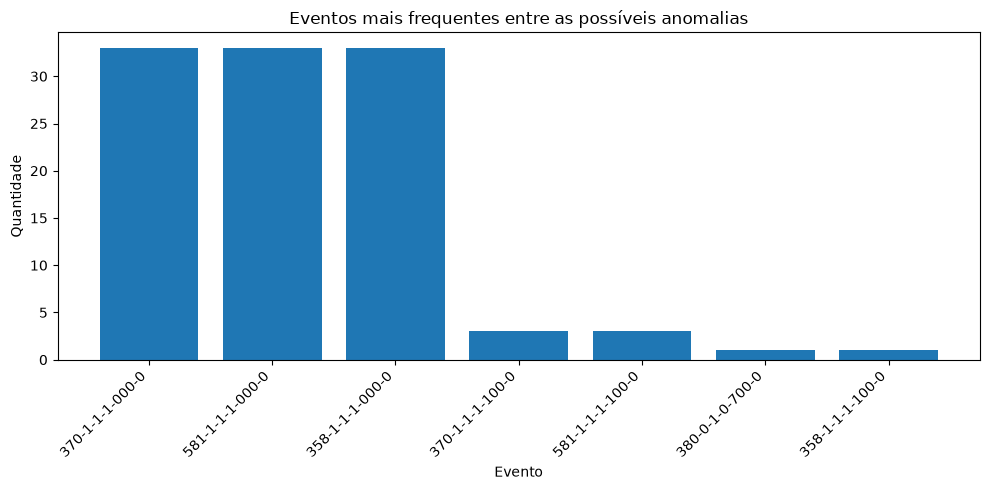

In [37]:
eventos_anomalias = (anomalias["evento"].value_counts().reset_index())

eventos_anomalias.columns = ["Evento","Quantidade"]

eventos_anomalias.head(10)

plt.figure(figsize=(10, 5))

plt.bar(eventos_anomalias["Evento"].head(10),eventos_anomalias["Quantidade"].head(10))

plt.title("Eventos mais frequentes entre as possíveis anomalias")
plt.xlabel("Evento")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

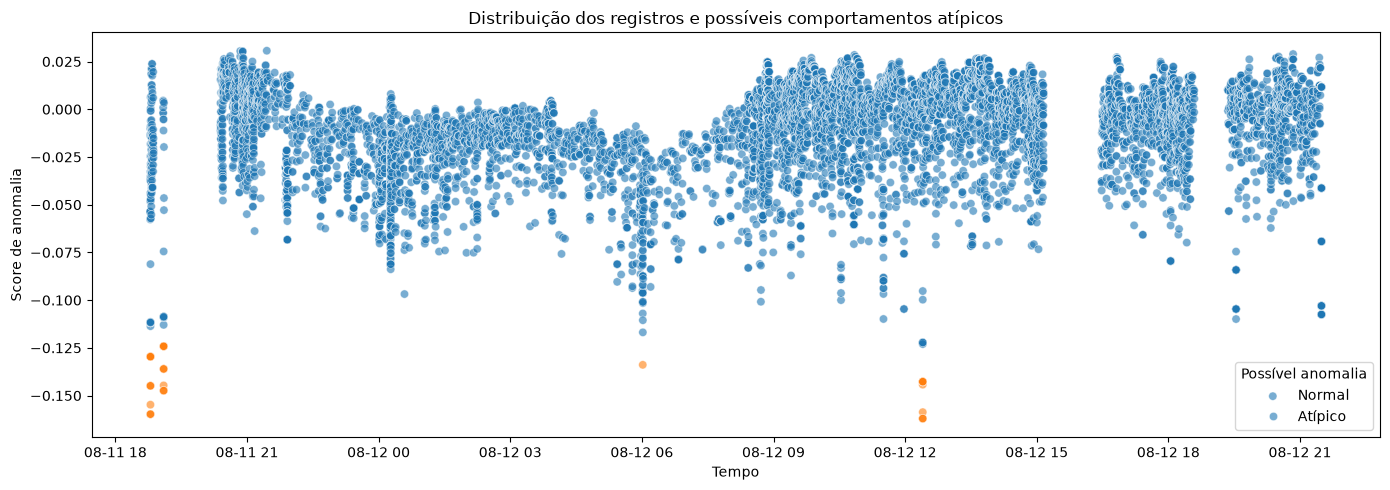

In [31]:
plt.figure(figsize=(14, 5))

sns.scatterplot(data=df,x="timestamp",y="score_v2",hue="possivel_anomalia",alpha=0.6)

plt.xlabel("Tempo")
plt.ylabel("Score de anomalia")
plt.title("Distribuição dos registros e possíveis comportamentos atípicos")
plt.legend(title="Possível anomalia",labels=["Normal", "Atípico"])

plt.tight_layout()
plt.show()

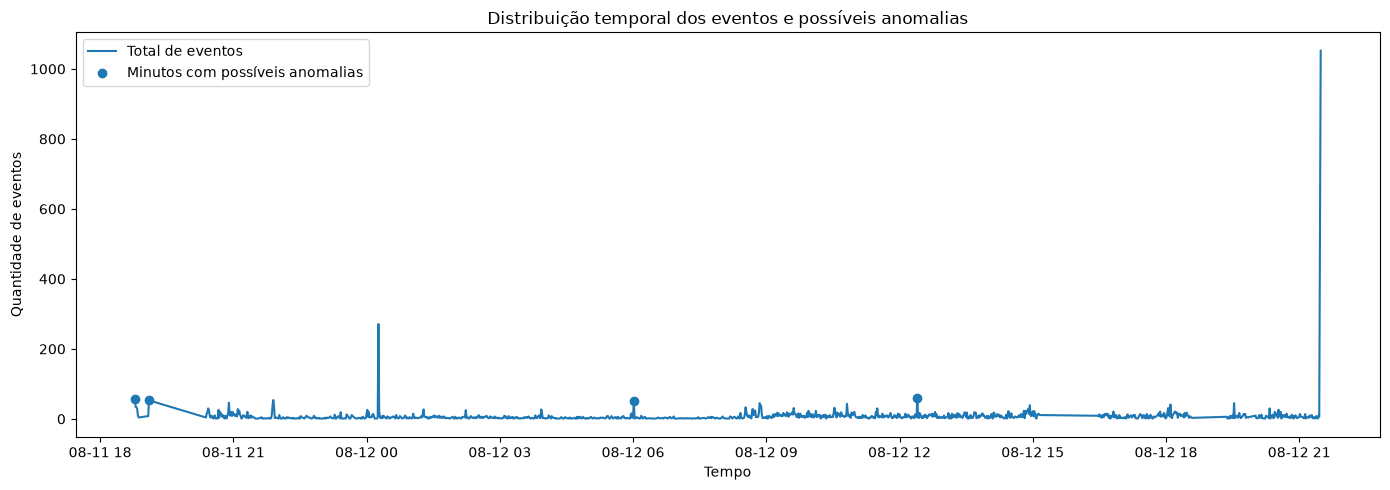

In [32]:
df["minuto_timestamp"] = df["timestamp"].dt.floor("min")

temporal = (df.groupby("minuto_timestamp").agg(total_eventos=("evento", "size"),possiveis_anomalias=("possivel_anomalia", "sum")).reset_index())

temporal.head()

plt.figure(figsize=(14, 5))

plt.plot(temporal["minuto_timestamp"],temporal["total_eventos"],label="Total de eventos")

plt.scatter(temporal.loc[temporal["possiveis_anomalias"] > 0,"minuto_timestamp"],temporal.loc[temporal["possiveis_anomalias"] > 0,"total_eventos"],label="Minutos com possíveis anomalias")

plt.xlabel("Tempo")
plt.ylabel("Quantidade de eventos")
plt.title("Distribuição temporal dos eventos e possíveis anomalias")
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
df_normal = df[df["score_v2"] > limite_v2].copy()

comparacao = pd.DataFrame({"Normal": [len(df_normal),df_normal["eventos_no_timestamp"].mean(),df_normal["frequencia_evento"].mean(),df_normal["frequencia_identificador"].mean()],"Possível anomalia": [len(anomalias),anomalias["eventos_no_timestamp"].mean(),anomalias["frequencia_evento"].mean(),anomalias["frequencia_identificador"].mean()]}, index=["Quantidade de registros","Eventos no mesmo timestamp (média)","Frequência do evento (média)","Frequência do identificador (média)"])

comparacao

,Normal,Possível anomalia
Quantidade de registros,9891.000000,107.000000
Eventos no mesmo timestamp (média),114.420382,47.962617
Frequência do evento (média),66.624305,31.560748
Frequência do identificador (média),506.757254,24.186916


In [39]:
horarios_comparacao = pd.DataFrame({"Normal": df_normal["hora_do_dia"].value_counts(),"Anomalias": anomalias["hora_do_dia"].value_counts()}).fillna(0)

horarios_comparacao = horarios_comparacao.sort_index()

horarios_comparacao

,Normal,Anomalias
hora_do_dia,,
0,582,0.0
1,288,0.0
2,262,0.0
3,224,0.0
4,129,0.0
5,177,0.0
6,156,1.0
7,84,0.0
8,466,0.0


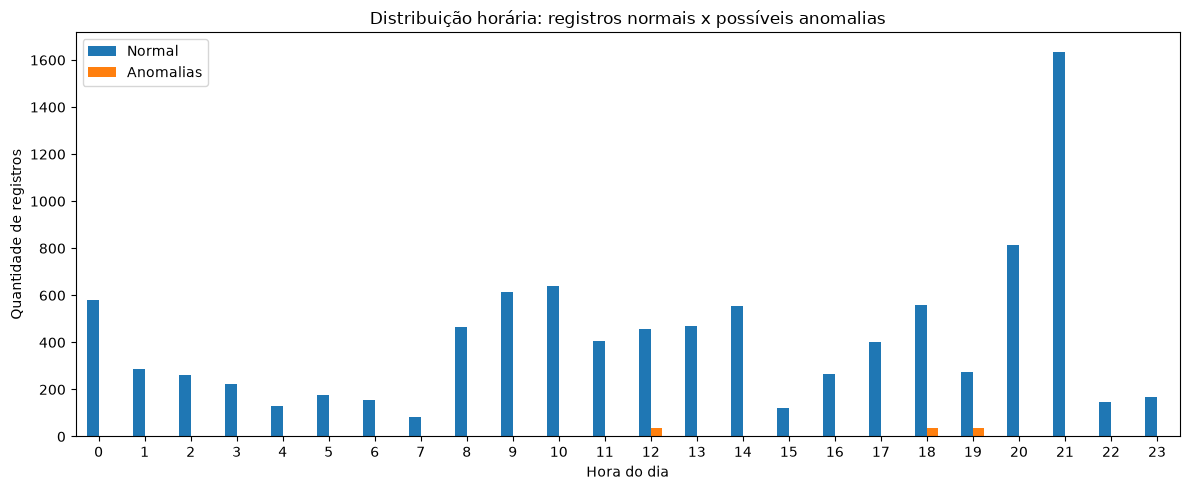

In [40]:
horarios_comparacao.plot(kind="bar",figsize=(12, 5))

plt.title("Distribuição horária: registros normais x possíveis anomalias")
plt.xlabel("Hora do dia")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
anomalias_evento_tempo = (anomalias.groupby(["timestamp", "evento"]).size().reset_index(name="quantidade").sort_values("quantidade", ascending=False))

anomalias_evento_tempo.head(15)

,timestamp,evento,quantidade
0,2014-08-11 18:47:57,370-1-1-1-000-0,33
2,2014-08-11 19:06:01,581-1-1-1-000-0,33
5,2014-08-12 12:24:06,358-1-1-1-000-0,33
1,2014-08-11 18:47:57,370-1-1-1-100-0,3
3,2014-08-11 19:06:01,581-1-1-1-100-0,3
4,2014-08-12 06:01:12,380-0-1-0-700-0,1
6,2014-08-12 12:24:06,358-1-1-1-100-0,1


In [42]:
episodios = (anomalias.groupby("timestamp").agg(registros=("evento", "size"),eventos=("evento", "nunique"),identificadores=("identificador", "nunique"),score_minimo=("score_v2", "min")).reset_index().sort_values("registros", ascending=False))

episodios.head(10)

,timestamp,registros,eventos,identificadores,score_minimo
0,2014-08-11 18:47:57,36,2,36,-0.159734
1,2014-08-11 19:06:01,36,2,36,-0.147402
3,2014-08-12 12:24:06,34,2,34,-0.162029
2,2014-08-12 06:01:12,1,1,1,-0.133883


In [43]:
comparacao_scores = pd.DataFrame({"score_v1": df["score_v1"],"score_v2": df["score_v2"]})

comparacao_scores.describe()

,score_v1,score_v2
count,9998.000000,9998.000000
mean,-0.002768,-0.013366
std,0.032871,0.028508
min,-0.135455,-0.162029
25%,-0.024460,-0.027111
50%,0.000751,-0.006740
75%,0.023418,0.008395
max,0.055789,0.030664


In [44]:
correlacao = df[["score_v1", "score_v2"]].corr()

correlacao

,score_v1,score_v2
score_v1,1.000000,0.551091
score_v2,0.551091,1.000000
